# Calculating median with quickselect


In [21]:
from random import randint, choice
import numpy as np
import sys

sys.setrecursionlimit(1500)


In [22]:
n = 501
series = [randint(1, 25) for i in range(n)]
print("Median is %0.1f" % np.median(series))


Median is 14.0


In [23]:
print("251st element of the ordered series is %0.1f" % sorted(series)[250])


251st element of the ordered series is 14.0


In [24]:
from typing import List


def quick_select(series: List[int], k: int):
    pivot = choice(series)

    left, right = list(), list()
    for item in series:
        if item < pivot:
            left.append(item)
        if item > pivot:
            right.append(item)

    length_left = len(left)
    if length_left > k:
        return quick_select(left, k)
    k -= length_left

    duplicates = len(series) - (length_left + len(right))
    if duplicates > k:
        return float(pivot)
    k -= duplicates

    return quick_select(right, k)


In [25]:
quick_select(series, 250)


14.0

In [26]:
def median(series):
    if len(series) % 2 != 0:
        return quick_select(series, len(series) // 2)
    else:
        left = quick_select(series, (len(series) - 1) // 2)
        right = quick_select(series, (len(series) + 1) // 2)
        return (left + right) / 2


In [27]:
median(series)


14.0

### MonteCarlo simulation


In [28]:
def quick_select(series: List[int], k: int, counter=0):
    pivot = choice(series)

    left, right = list(), list()
    for item in series:
        if item < pivot:
            left.append(item)
        if item > pivot:
            right.append(item)

    counter += len(series)

    length_left = len(left)
    if length_left > k:
        return quick_select(left, k, counter)
    k -= length_left

    duplicates = series.count(pivot)
    if duplicates > k:
        return float(pivot), counter
    k -= duplicates

    return quick_select(right, k, counter)


In [29]:
results = list()
for run in range(1000):
    n = 1001
    series = [randint(1, 25) for i in range(n)]
    median, count = quick_select(series, n // 2)
    assert median == np.median(series)
    results.append(count)

print("Mean operations: %i" % np.mean(results))


Mean operations: 2737


In [30]:
import matplotlib.pyplot as plt


In [31]:
%matplotlib inline

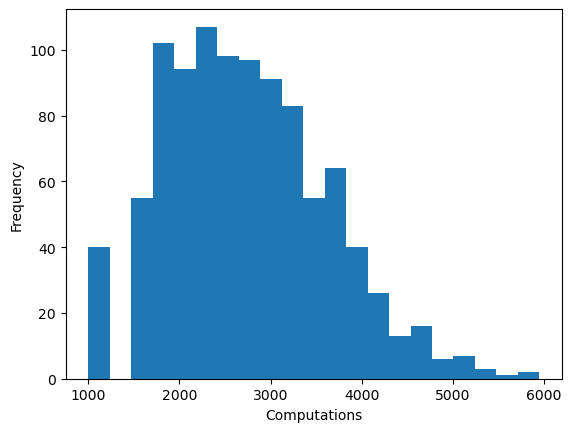

In [32]:
plt.hist(results, bins="auto")
plt.xlabel("Computations")
plt.ylabel("Frequency")
plt.show()


In [33]:
input_size = [501, 1001, 5001, 10001, 20001, 50001]
computations = list()
for n in input_size:
    results = list()
    for run in range(1000):
        series = [randint(1, 25) for i in range(n)]
        median, count = quick_select(series, n // 2)
        assert median == np.median(series)
        results.append(count)
    computations.append(np.mean(results))


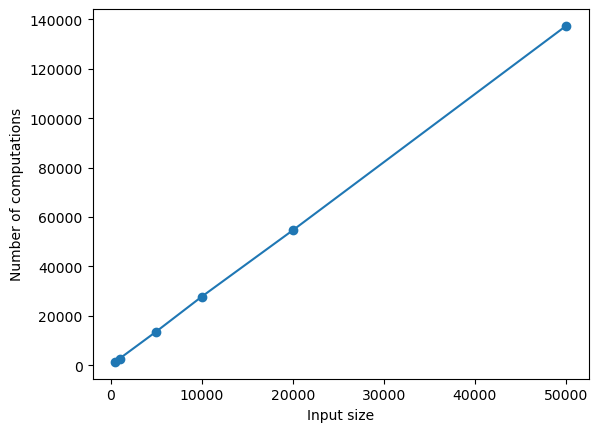

In [34]:
plt.plot(input_size, computations, "-o")
plt.xlabel("Input size")
plt.ylabel("Number of computations")
plt.show()


### Quicksort


In [41]:
def choose_leftmost(l):
    return l[0]


In [36]:
def quicksort(series, get):

    try:
        global operations
        operations += len(series)
    except:
        pass

    if len(series) <= 3:
        return sorted(series)

    pivot = get(series)
    duplicates = series.count(pivot)

    left, right = list(), list()
    for item in series:
        if item < pivot:
            left.append(item)
        if item > pivot:
            right.append(item)

    return quicksort(left, get) + [pivot] * duplicates + quicksort(right, get)


In [37]:
series = list(range(25))
operations = 0
sorted_list = quicksort(series, choose_leftmost)
print("Operations: %i" % operations)


Operations: 322


In [38]:
def choose_random(l):
    return choice(l)


In [39]:
series = [randint(1, 25) for i in range(25)]
operations = 0
sorted_list = quicksort(series, choose_random)
print("Operations: %i" % operations)


Operations: 84


In [40]:
np.log(25) * 25


80.47189562170502